# BrightSpot — Classical Seg + Soft Map Evaluation

Evaluates outputs of `compute_soft_maps.py` for all 60 training cases:
- `classical_seg.nii` vs ground truth `wmh.nii` → DICE, HD95, Lesion F1
- `soft_map.nii` → visual inspection (is it non-zero? does it highlight right regions?)

Saves `outputs/classical_results.csv` for later ablation comparison.

In [2]:
import sys
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

REPO_ROOT      = Path('/data/users/ssethi2/mmml_repos/guided-brightspot')
sys.path.insert(0, str(REPO_ROOT))
from evaluation.metrics import evaluate_case

PROCESSED_ROOT = REPO_ROOT / 'data' / 'processed' / 'training'
SITES          = ['Utrecht', 'Singapore', 'Amsterdam/GE3T']
TARGET_SPACING = (1.0, 1.0, 3.0)

def load_arr(path):
    return sitk.GetArrayFromImage(sitk.ReadImage(str(path)))

def normalize_display(arr):
    mn, mx = arr.min(), arr.max()
    return (arr.astype(float) - mn) / (mx - mn) if mx > mn else np.zeros_like(arr, dtype=float)

def best_slice(wmh_arr):
    counts = wmh_arr.sum(axis=(1, 2))
    best = int(counts.argmax())
    return best if counts[best] > 0 else wmh_arr.shape[0] // 2

## 1. Evaluate classical_seg vs ground truth — all 60 cases

In [3]:
results = []

for site in SITES:
    site_dir = PROCESSED_ROOT / site
    if not site_dir.exists():
        print(f'WARNING: {site_dir} not found, skipping')
        continue

    for patient_dir in sorted(site_dir.iterdir(), key=lambda x: x.name):
        classical_path = patient_dir / 'classical_seg.nii'
        gt_path        = patient_dir / 'wmh.nii'
        soft_path      = patient_dir / 'soft_map.nii'

        if not classical_path.exists() or not gt_path.exists():
            print(f'WARNING: missing files for {site}/{patient_dir.name}, skipping')
            continue

        pred_arr = load_arr(classical_path)
        gt_arr   = load_arr(gt_path)

        metrics = evaluate_case(pred_arr, gt_arr, spacing=TARGET_SPACING)
        metrics['site']       = site
        metrics['patient_id'] = patient_dir.name

        # Soft map stats
        if soft_path.exists():
            sm = load_arr(soft_path).astype(float)
            metrics['soft_map_max']    = round(float(sm.max()), 4)
            metrics['soft_map_nonzero'] = int((sm > 0).sum())
        else:
            metrics['soft_map_max']    = None
            metrics['soft_map_nonzero'] = None

        results.append(metrics)

        empty_flag = ' ← EMPTY SEG' if pred_arr.sum() == 0 else ''
        print(f"{site:<20} {patient_dir.name:<6} "
              f"DICE={metrics['dice']:.3f}  "
              f"HD95={metrics['hausdorff95'] if metrics['hausdorff95'] != float('inf') else 'inf':<8}  "
              f"F1={metrics['f1']:.3f}  "
              f"GT={metrics['n_gt_lesions']}  Pred={metrics['n_pred_lesions']}  "
              f"SoftMax={metrics['soft_map_max']}{empty_flag}")

df = pd.DataFrame(results)
print(f'\nTotal cases evaluated: {len(df)}')
print(f'Cases with empty classical_seg: {(df["dice"] == 0).sum()} '
      f'(soft_map still non-zero for all: {(df["soft_map_max"] == 0).sum() == 0})')

Utrecht              0      DICE=0.000  HD95=87.77     F1=0.000  GT=118  Pred=24  SoftMax=1.0
Utrecht              11     DICE=0.000  HD95=80.93     F1=0.000  GT=69  Pred=26  SoftMax=1.0
Utrecht              17     DICE=0.000  HD95=61.8      F1=0.000  GT=49  Pred=18  SoftMax=1.0
Utrecht              19     DICE=0.000  HD95=59.85     F1=0.000  GT=109  Pred=31  SoftMax=1.0
Utrecht              2      DICE=0.007  HD95=46.65     F1=0.000  GT=178  Pred=28  SoftMax=0.9994
Utrecht              21     DICE=0.004  HD95=61.93     F1=0.000  GT=150  Pred=19  SoftMax=0.9999
Utrecht              23     DICE=0.000  HD95=58.83     F1=0.000  GT=27  Pred=18  SoftMax=1.0
Utrecht              25     DICE=0.007  HD95=58.83     F1=0.000  GT=53  Pred=23  SoftMax=1.0
Utrecht              27     DICE=0.000  HD95=52.4      F1=0.000  GT=22  Pred=14  SoftMax=1.0
Utrecht              29     DICE=0.010  HD95=63.0      F1=0.000  GT=110  Pred=33  SoftMax=1.0
Utrecht              31     DICE=0.007  HD95=56.03     F1=0

## 2. Summary statistics — overall and per site

In [4]:
def summarize(df, label=''):
    finite_hd = df[df['hausdorff95'] != np.inf]['hausdorff95']
    n_inf     = (df['hausdorff95'] == np.inf).sum()
    n_empty   = (df['n_pred_lesions'] == 0).sum()

    print(f"\n{'='*55}")
    print(f" {label} (n={len(df)})")
    print(f"{'='*55}")
    print(f"  DICE        mean={df['dice'].mean():.3f}  std={df['dice'].std():.3f}  "
          f"min={df['dice'].min():.3f}  max={df['dice'].max():.3f}")
    print(f"  HD95 (mm)   mean={finite_hd.mean():.1f}  std={finite_hd.std():.1f}  "
          f"(inf: {n_inf})")
    print(f"  Precision   mean={df['precision'].mean():.3f}  std={df['precision'].std():.3f}")
    print(f"  Recall      mean={df['recall'].mean():.3f}  std={df['recall'].std():.3f}")
    print(f"  Lesion F1   mean={df['f1'].mean():.3f}  std={df['f1'].std():.3f}")
    print(f"  Empty segs: {n_empty}/{len(df)} cases")
    if 'soft_map_max' in df.columns:
        n_zero_sm = (df['soft_map_max'] == 0).sum()
        print(f"  Zero soft maps: {n_zero_sm}/{len(df)} cases")

summarize(df, label='ALL SITES — Classical Segmentation')
for site in SITES:
    summarize(df[df['site'] == site], label=site)


 ALL SITES — Classical Segmentation (n=60)
  DICE        mean=0.146  std=0.198  min=0.000  max=0.746
  HD95 (mm)   mean=60.1  std=15.0  (inf: 0)
  Precision   mean=0.043  std=0.069
  Recall      mean=0.019  std=0.025
  Lesion F1   mean=0.025  std=0.035
  Empty segs: 0/60 cases
  Zero soft maps: 0/60 cases

 Utrecht (n=20)
  DICE        mean=0.007  std=0.012  min=0.000  max=0.043
  HD95 (mm)   mean=61.6  std=11.9  (inf: 0)
  Precision   mean=0.000  std=0.000
  Recall      mean=0.000  std=0.000
  Lesion F1   mean=0.000  std=0.000
  Empty segs: 0/20 cases
  Zero soft maps: 0/20 cases

 Singapore (n=20)
  DICE        mean=0.228  std=0.191  min=0.000  max=0.615
  HD95 (mm)   mean=68.9  std=7.7  (inf: 0)
  Precision   mean=0.033  std=0.024
  Recall      mean=0.024  std=0.015
  Lesion F1   mean=0.027  std=0.016
  Empty segs: 0/20 cases
  Zero soft maps: 0/20 cases

 Amsterdam/GE3T (n=20)
  DICE        mean=0.202  std=0.234  min=0.000  max=0.746
  HD95 (mm)   mean=49.7  std=17.2  (inf: 0)
  P

## 3. Metric distributions by site

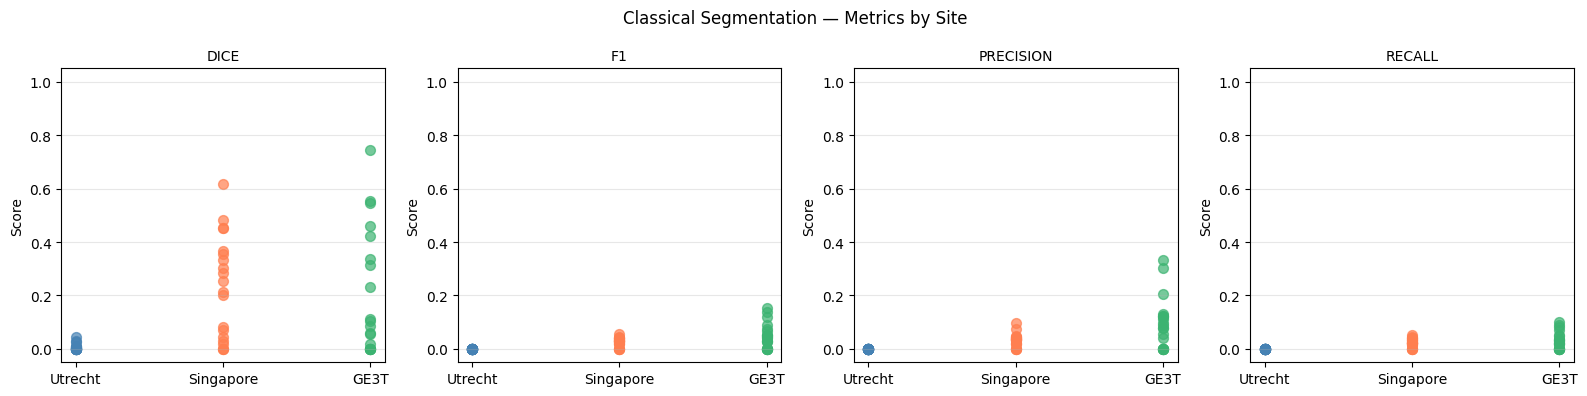

In [5]:
metrics_to_plot = ['dice', 'f1', 'precision', 'recall']
site_colors     = {'Utrecht': 'steelblue', 'Singapore': 'coral', 'Amsterdam/GE3T': 'mediumseagreen'}

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    for site, color in site_colors.items():
        site_df  = df[df['site'] == site]
        xs       = [site.split('/')[-1]] * len(site_df)
        ax.scatter(xs, site_df[metric], color=color, alpha=0.7, s=50)
        mean_val = site_df[metric].mean()
        ax.hlines(mean_val, site.split('/')[-1], site.split('/')[-1],
                  colors=color, linewidth=4)
    ax.set_title(metric.upper(), fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Classical Segmentation — Metrics by Site', fontsize=12)
plt.tight_layout()
plt.savefig('classical_metrics_by_site.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Soft map health check

In [6]:
zero_soft = df[df['soft_map_max'] == 0]
empty_seg = df[df['n_pred_lesions'] == 0]

print(f'Cases with zero soft_map: {len(zero_soft)}')
if len(zero_soft) > 0:
    print(zero_soft[['site', 'patient_id', 'dice', 'soft_map_max']].to_string(index=False))

print(f'\nCases with empty classical_seg (pred_lesions=0): {len(empty_seg)}')
print(empty_seg[['site', 'patient_id', 'dice', 'n_gt_lesions', 'soft_map_max']].to_string(index=False))

print('\nKey check: soft_map should be non-zero even when classical_seg is empty.')
both_empty = df[(df['n_pred_lesions'] == 0) & (df['soft_map_max'] == 0)]
if len(both_empty) == 0:
    print('PASS — no cases where both classical_seg AND soft_map are empty.')
else:
    print(f'FAIL — {len(both_empty)} cases where both are empty:')
    print(both_empty[['site', 'patient_id']].to_string(index=False))

Cases with zero soft_map: 0

Cases with empty classical_seg (pred_lesions=0): 0
Empty DataFrame
Columns: [site, patient_id, dice, n_gt_lesions, soft_map_max]
Index: []

Key check: soft_map should be non-zero even when classical_seg is empty.
PASS — no cases where both classical_seg AND soft_map are empty.


## 5. Visual inspection — best, median, worst DICE
5 columns: FLAIR | Ground Truth | Classical Seg | Soft Map | GT+Pred Overlay

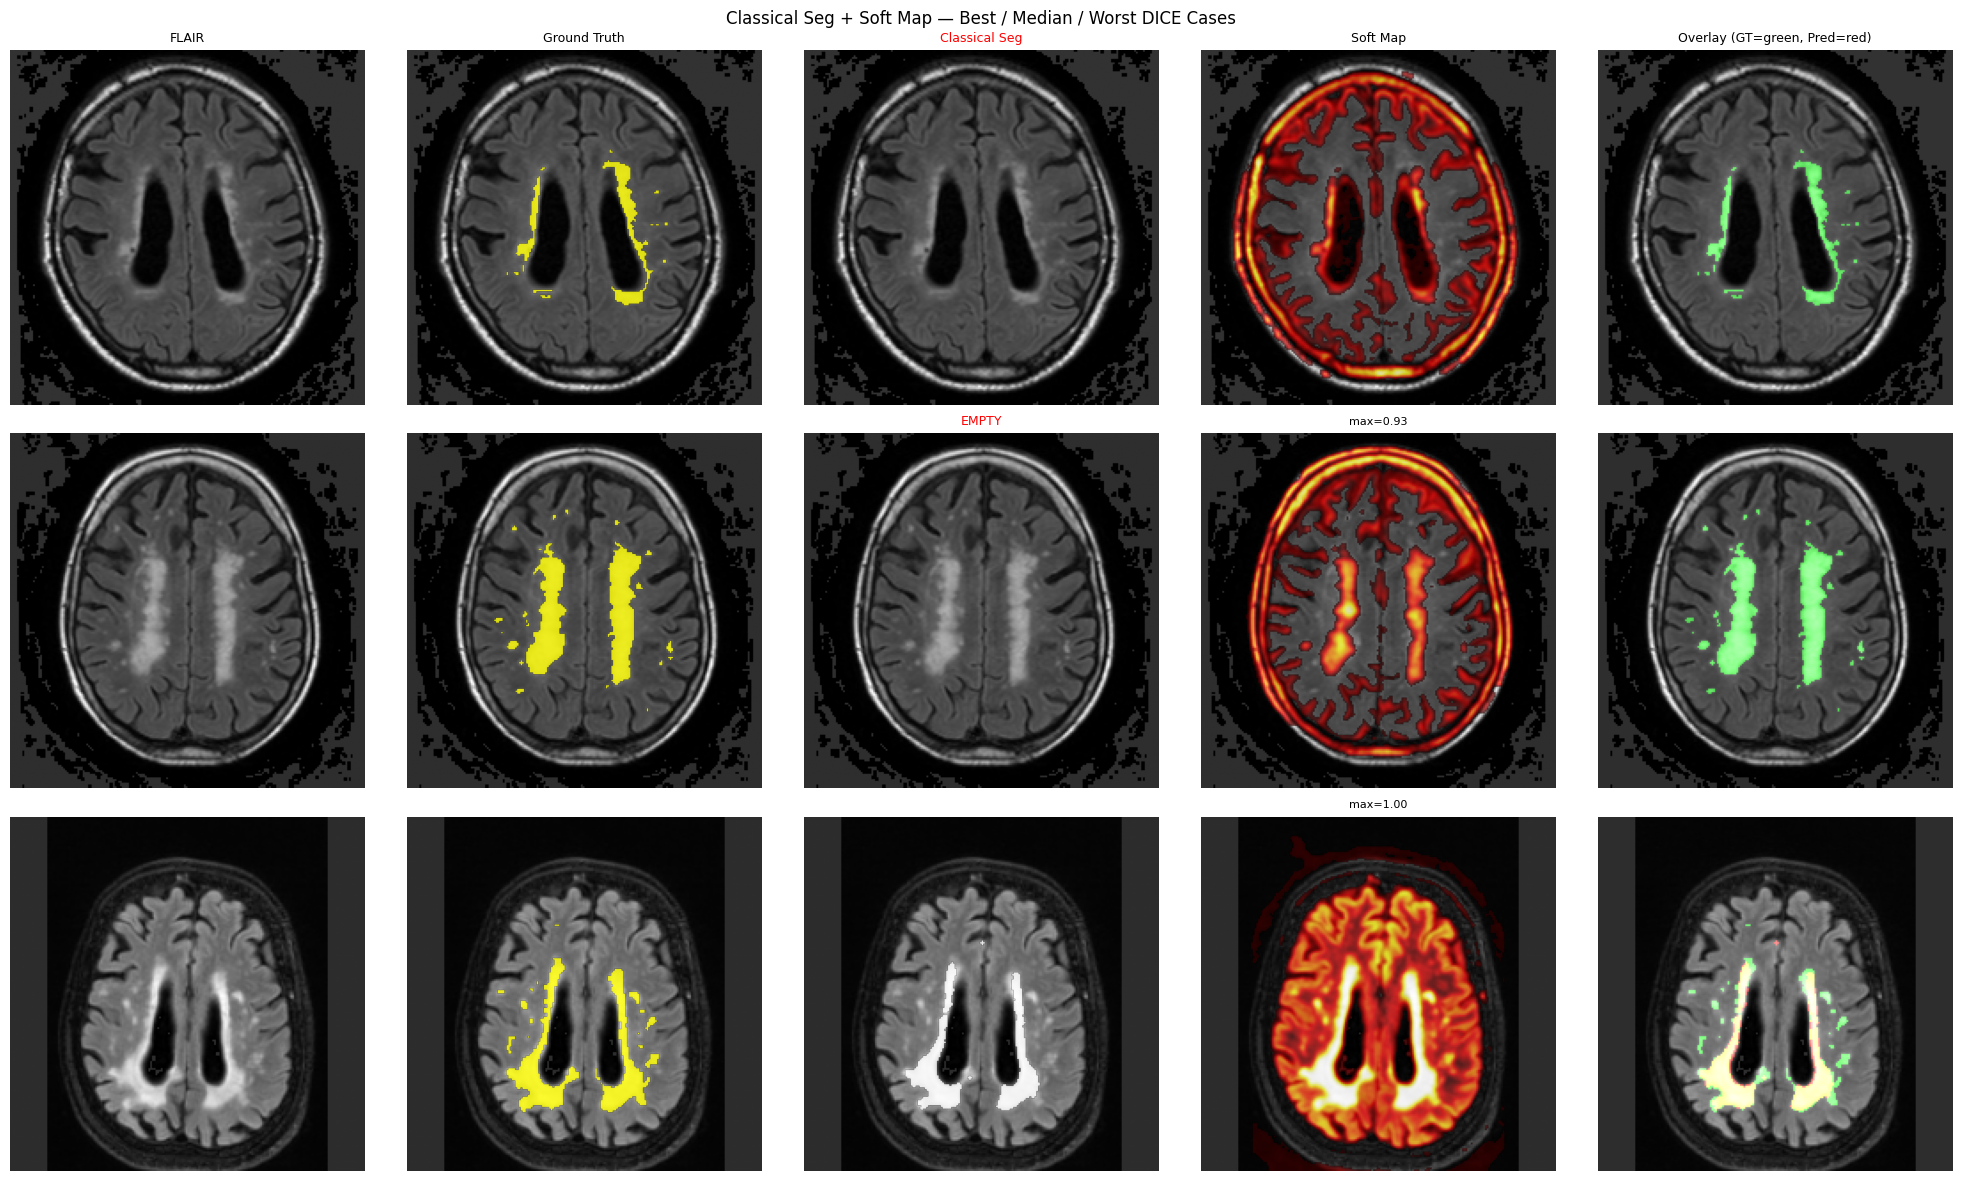

Saved to ../visualizations/classical_and_softmap_qualitative.png


In [9]:
df_sorted = df.sort_values('dice')
cases_to_show = {
    f"Worst  (DICE={df_sorted.iloc[0]['dice']:.3f})": df_sorted.iloc[0],
    f"Median (DICE={df_sorted.iloc[len(df_sorted)//2]['dice']:.3f})": df_sorted.iloc[len(df_sorted)//2],
    f"Best   (DICE={df_sorted.iloc[-1]['dice']:.3f})": df_sorted.iloc[-1],
}

col_labels = ['FLAIR', 'Ground Truth', 'Classical Seg', 'Soft Map', 'Overlay (GT=green, Pred=red)']
fig, axes = plt.subplots(len(cases_to_show), 5, figsize=(20, 4 * len(cases_to_show)))

for row, (label, case_row) in enumerate(cases_to_show.items()):
    site = case_row['site']
    pid  = str(case_row['patient_id'])
    pdir = PROCESSED_ROOT / site / pid

    flair_arr = load_arr(pdir / 'FLAIR.nii')
    gt_arr    = load_arr(pdir / 'wmh.nii')
    pred_arr  = load_arr(pdir / 'classical_seg.nii')
    soft_arr  = load_arr(pdir / 'soft_map.nii').astype(float)

    sl    = best_slice(gt_arr)
    f_sl  = flair_arr[sl]
    g_sl  = gt_arr[sl]
    p_sl  = pred_arr[sl]
    sm_sl = soft_arr[sl]

    ax = axes[row]

    # FLAIR
    ax[0].imshow(normalize_display(f_sl), cmap='gray')
    ax[0].set_ylabel(f'{label}\n{site.split("/")[-1]}/{pid}\nslice {sl}', fontsize=8)

    # Ground truth overlay on FLAIR
    ax[1].imshow(normalize_display(f_sl), cmap='gray')
    ax[1].imshow(np.ma.masked_where(g_sl == 0, g_sl), cmap='autumn', alpha=0.8, vmin=0, vmax=1)

    # Classical seg overlay on FLAIR
    ax[2].imshow(normalize_display(f_sl), cmap='gray')
    if p_sl.max() > 0:
        ax[2].imshow(np.ma.masked_where(p_sl == 0, p_sl), cmap='hot', alpha=0.8, vmin=0, vmax=1)
    else:
        ax[2].set_title('EMPTY', fontsize=9, color='red')

    # Soft map heatmap on FLAIR
    ax[3].imshow(normalize_display(f_sl), cmap='gray')
    ax[3].imshow(np.ma.masked_where(sm_sl < 0.05, sm_sl), cmap='hot', alpha=0.7, vmin=0, vmax=1)
    ax[3].set_title(f'max={sm_sl.max():.2f}', fontsize=8)

    # GT vs Pred overlay: GT=green, Pred=red, overlap=yellow
    flair_norm = normalize_display(f_sl)
    overlay    = np.stack([flair_norm, flair_norm, flair_norm], axis=-1)
    overlay[:, :, 1] = np.clip(overlay[:, :, 1] + 0.5 * g_sl, 0, 1)
    overlay[:, :, 0] = np.clip(overlay[:, :, 0] + 0.5 * p_sl, 0, 1)
    ax[4].imshow(overlay)

    for i, a in enumerate(ax):
        if row == 0:
            a.set_title(col_labels[i], fontsize=9)
        a.axis('off')

plt.suptitle('Classical Seg + Soft Map — Best / Median / Worst DICE Cases', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizations/classical_and_softmap_qualitative.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to ../visualizations/classical_and_softmap_qualitative.png')

## 6. Visual inspection — cases where classical_seg is empty
Confirms soft_map is still meaningful even when classical pipeline finds nothing

In [10]:
empty_cases = df[df['n_pred_lesions'] == 0].head(4)  # show up to 4

if len(empty_cases) == 0:
    print('No cases with empty classical_seg — nothing to show here.')
else:
    fig, axes = plt.subplots(len(empty_cases), 5, figsize=(20, 4 * len(empty_cases)))
    if len(empty_cases) == 1:
        axes = [axes]

    col_labels = ['FLAIR', 'Ground Truth', 'Classical Seg (empty)', 'Soft Map', 'GT overlay']

    for row, (_, case_row) in enumerate(empty_cases.iterrows()):
        site = case_row['site']
        pid  = str(case_row['patient_id'])
        pdir = PROCESSED_ROOT / site / pid

        flair_arr = load_arr(pdir / 'FLAIR.nii')
        gt_arr    = load_arr(pdir / 'wmh.nii')
        pred_arr  = load_arr(pdir / 'classical_seg.nii')
        soft_arr  = load_arr(pdir / 'soft_map.nii').astype(float)

        sl    = best_slice(gt_arr)
        f_sl  = flair_arr[sl]
        g_sl  = gt_arr[sl]
        sm_sl = soft_arr[sl]

        ax = axes[row]

        ax[0].imshow(normalize_display(f_sl), cmap='gray')
        ax[0].set_ylabel(f'{site.split("/")[-1]}/{pid}\nGT lesions={case_row["n_gt_lesions"]}\nDICE={case_row["dice"]:.3f}',
                         fontsize=8)
        ax[1].imshow(normalize_display(f_sl), cmap='gray')
        ax[1].imshow(np.ma.masked_where(g_sl == 0, g_sl), cmap='autumn', alpha=0.8)
        ax[2].imshow(normalize_display(f_sl), cmap='gray')
        ax[2].set_title('EMPTY', fontsize=10, color='red')
        ax[3].imshow(normalize_display(f_sl), cmap='gray')
        ax[3].imshow(np.ma.masked_where(sm_sl < 0.05, sm_sl), cmap='hot', alpha=0.7, vmin=0, vmax=1)
        ax[3].set_title(f'soft max={sm_sl.max():.2f}', fontsize=8)
        flair_norm = normalize_display(f_sl)
        overlay    = np.stack([flair_norm, flair_norm, flair_norm], axis=-1)
        overlay[:, :, 1] = np.clip(overlay[:, :, 1] + 0.5 * g_sl, 0, 1)
        ax[4].imshow(overlay)

        for i, a in enumerate(ax):
            if row == 0:
                a.set_title(col_labels[i], fontsize=9)
            a.axis('off')

    plt.suptitle('Empty Classical Seg Cases — Soft Map Still Non-Zero?', fontsize=12)
    plt.tight_layout()
    plt.savefig('empty_seg_softmap_check.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to empty_seg_softmap_check.png')

No cases with empty classical_seg — nothing to show here.


## 7. Save results to CSV

In [11]:
out_csv = REPO_ROOT / 'outputs' / 'classical_results.csv'
out_csv.parent.mkdir(parents=True, exist_ok=True)
df['method'] = 'classical'
df.to_csv(out_csv, index=False)
print(f'Saved to {out_csv}')
print('\nLoad this CSV later alongside U-Net and guided U-Net results for final ablation comparison.')

Saved to /data/users/ssethi2/mmml_repos/guided-brightspot/outputs/classical_results.csv

Load this CSV later alongside U-Net and guided U-Net results for final ablation comparison.
